# DNABERT2 Full Fine-Tuning: Kaggle GPU Profile

This notebook is the Kaggle port of the pinned DNABERT2-117M benchmark. It
uses Kaggle's Python environment, a Kaggle Dataset for the three CSV splits,
and `/kaggle/working` for checkpoints and results.

**Required runtime:** Kaggle Notebook with an NVIDIA GPU and Internet enabled.


## Fixed scientific contract

The model comparison rules remain unchanged:

| Setting | Kaggle profile |
| --- | --- |
| Dataset | Shared GSE144621 predefined CSV splits |
| Seed | 42 |
| Backbone | `zhihan1996/DNABERT-2-117M`, pinned repository revision |
| Training scope | Full encoder fine-tuning |
| Pooling | Mean pooling |
| Optimizer | AdamW |
| Threshold | Selected on validation MCC only |
| Final reporting | Held-out test MCC and AUPRC |

The notebook uses the checked-in TOML as the source of truth for batch size,
learning rate, epoch count, precision, and checkpointing. The original Colab
notebook's prose and assertions disagree about some of those values; this port
reports the values actually loaded from the TOML instead of silently changing
the experiment.


## 1. Select and benchmark the Kaggle GPU

In Kaggle Notebook options, select **T4 x2** first. The current pinned
SeqTrainer benchmark command is single-process, so it does not automatically
turn two T4s into a distributed run. This cell benchmarks every visible GPU
and the run cell pins training to the fastest one. If you need a strict
multi-GPU run, the SeqTrainer benchmark itself must first be made DDP-aware.


In [1]:
import gc
import subprocess
import time
import torch

try:
    gpu_info = subprocess.check_output(
        [
            "nvidia-smi",
            "--query-gpu=name,memory.total,driver_version",
            "--format=csv,noheader",
        ],
        text=True,
    ).strip()
except Exception as exc:
    gpu_info = f"nvidia-smi unavailable: {exc}"

print("GPU:", gpu_info)
if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA is not available. In Kaggle, open Notebook options and select "
        "an NVIDIA GPU accelerator before running the notebook."
    )

GPU_COUNT = torch.cuda.device_count()
GPU_NAMES = [torch.cuda.get_device_name(i) for i in range(GPU_COUNT)]
print("Visible CUDA devices:", GPU_COUNT)
for i, name in enumerate(GPU_NAMES):
    memory_gib = torch.cuda.get_device_properties(i).total_memory / 1024**3
    print(f"  cuda:{i}: {name} ({memory_gib:.2f} GiB)")


def benchmark_gpu(device_index, repetitions=30):
    device = torch.device(f"cuda:{device_index}")
    # A short FP16 GEMM probe approximates the workload's tensor operations.
    left = torch.randn((2048, 2048), device=device, dtype=torch.float16)
    right = torch.randn((2048, 2048), device=device, dtype=torch.float16)
    for _ in range(5):
        torch.mm(left, right)
    torch.cuda.synchronize(device)
    start = time.perf_counter()
    for _ in range(repetitions):
        torch.mm(left, right)
    torch.cuda.synchronize(device)
    elapsed = time.perf_counter() - start
    score = repetitions / elapsed
    del left, right
    torch.cuda.empty_cache()
    gc.collect()
    return score


gpu_scores = {i: benchmark_gpu(i) for i in range(GPU_COUNT)}
SELECTED_GPU_INDEX = max(gpu_scores, key=gpu_scores.get)
print("FP16 probe (higher is faster):")
for i, score in gpu_scores.items():
    print(f"  cuda:{i}: {score:.2f} GEMM iterations/sec")
print(
    "Selected GPU:",
    f"cuda:{SELECTED_GPU_INDEX} ({GPU_NAMES[SELECTED_GPU_INDEX]})",
)


GPU: Tesla T4, 15360 MiB, 580.159.04
Tesla T4, 15360 MiB, 580.159.04
Visible CUDA devices: 2
  cuda:0: Tesla T4 (14.56 GiB)
  cuda:1: Tesla T4 (14.56 GiB)
FP16 probe (higher is faster):
  cuda:0: 1288.89 GEMM iterations/sec
  cuda:1: 1052.75 GEMM iterations/sec
Selected GPU: cuda:0 (Tesla T4)


## 2. Set reproducible paths and versions

In [2]:
import os
import shutil
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/simplyshree/SeqTrainer.git"
SEQTRAINER_BRANCH = "issue-3-model-baselines-clean"
SEQTRAINER_COMMIT = "5e6c8443767757afb759d3d6c744433e45e73530"

REPO_DIR = Path("/kaggle/working/SeqTrainer")
KAGGLE_INPUT_ROOT = Path("/kaggle/input")
KAGGLE_DATA_DIR = None  # Optional: Path("/kaggle/input/<your-dataset-slug>")
LOCAL_DATA_DIR = REPO_DIR / "data" / "promoter_classification"
OUTPUT_DIR = Path("/kaggle/working/dnabert2_final_training_t4_seed42")

HF_HOME = Path("/kaggle/working/huggingface")
PIP_CACHE_DIR = Path("/kaggle/working/pip-cache")
CONFIG_RELATIVE_PATH = Path(
    "notebooks/benchmarks/dnabert2/config.toml"
)

print("Pinned SeqTrainer commit:", SEQTRAINER_COMMIT)
print("Kaggle input root:", KAGGLE_INPUT_ROOT)
print("Result directory:", OUTPUT_DIR)


Pinned SeqTrainer commit: 659cb28a59b44057607329babf16b196b69b1e6f
Kaggle input root: /kaggle/input
Result directory: /kaggle/working/dnabert2_final_training_t4_seed42


## 3. Install the benchmark dependencies in Kaggle's current kernel

Kaggle already supplies a CUDA-enabled PyTorch build. The install cell keeps
that build and installs the benchmark's Python dependencies around it; this
avoids replacing Kaggle's GPU stack with a CPU or incompatible wheel.

**Before running:** turn on both **GPU** and **Internet** in Kaggle Notebook
options. Internet is needed for GitHub and the public Hugging Face model.


In [3]:
install_env = os.environ.copy()
install_env["PIP_CACHE_DIR"] = str(PIP_CACHE_DIR)

kaggle_packages = [
    "transformers==4.41.2",
    "tokenizers==0.19.1",
    "huggingface-hub==0.23.5",
    "einops==0.6.1",
    "packaging",
    "accelerate==0.30.1",
]

subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "--upgrade",
        "--force-reinstall",
        "--no-deps",
        *kaggle_packages,
    ],
    check=True,
    env=install_env,
)

import numpy
import pandas
import sklearn
import torch
import transformers
import huggingface_hub

print("Dependencies installed into:", sys.executable)
print("torch:", torch.__version__)
print("numpy:", numpy.__version__)
print("pandas:", pandas.__version__)
print("scikit-learn:", sklearn.__version__)
print("transformers:", transformers.__version__)
print("huggingface-hub:", huggingface_hub.__version__)

COMPAT_DIR = Path("/kaggle/working/dnabert2_kaggle_compat")
COMPAT_DIR.mkdir(parents=True, exist_ok=True)

(COMPAT_DIR / "sitecustomize.py").write_text(
    r'''try:
    import functools
    from torch.utils.checkpoint import checkpoint as torch_checkpoint

    from transformers.models.auto.auto_factory import _BaseAutoModelClass
    from transformers.modeling_utils import PreTrainedModel

    # Fix DNABERT2 dynamic BertConfig registration with Transformers 4.41.
    _original_register = _BaseAutoModelClass.register.__func__

    def _register_remote_config_compat(
        cls,
        config_class,
        model_class,
        exist_ok=False,
    ):
        model_config_class = getattr(model_class, "config_class", None)

        if (
            model_config_class is not None
            and model_config_class is not config_class
        ):
            return cls._model_mapping.register(
                config_class,
                model_class,
                exist_ok=exist_ok,
            )

        return _original_register(
            cls,
            config_class,
            model_class,
            exist_ok=exist_ok,
        )

    _BaseAutoModelClass.register = classmethod(
        _register_remote_config_compat
    )

    # Fix DNABERT2's older gradient-checkpointing API.
    _original_gradient_checkpointing_enable = (
        PreTrainedModel.gradient_checkpointing_enable
    )

    def _gradient_checkpointing_enable_compat(
        self,
        gradient_checkpointing_kwargs=None,
    ):
        try:
            return _original_gradient_checkpointing_enable(
                self,
                gradient_checkpointing_kwargs=gradient_checkpointing_kwargs,
            )
        except ValueError as exc:
            if "not compatible with gradient checkpointing" not in str(exc):
                raise

            checkpoint_kwargs = dict(
                gradient_checkpointing_kwargs or {}
            )
            use_reentrant = checkpoint_kwargs.pop(
                "use_reentrant",
                False,
            )

            self._gradient_checkpointing_func = functools.partial(
                torch_checkpoint,
                use_reentrant=use_reentrant,
                **checkpoint_kwargs,
            )

            for module in self.modules():
                if (
                    module.__class__.__name__
                    in {"BertEncoder", "BertModel"}
                    or hasattr(module, "gradient_checkpointing")
                ):
                    module.gradient_checkpointing = True

            if hasattr(self, "config"):
                self.config.gradient_checkpointing = True

            print(
                "Enabled DNABERT2 legacy gradient checkpointing fallback"
            )

    PreTrainedModel.gradient_checkpointing_enable = (
        _gradient_checkpointing_enable_compat
    )

except Exception as exc:
    print(
        "DNABERT2 compatibility shim was not applied:",
        repr(exc),
    )
''',
    encoding="utf-8",
)

print(
    "DNABERT2 compatibility shim:",
    COMPAT_DIR / "sitecustomize.py",
)

     ???????????????????????????????????????? 43.8/43.8 kB 2.3 MB/s eta 0:00:00
   ???????????????????????????????????????? 9.1/9.1 MB 87.9 MB/s eta 0:00:00
   ???????????????????????????????????????? 3.6/3.6 MB 117.6 MB/s eta 0:00:00
   ???????????????????????????????????????? 402.8/402.8 kB 38.5 MB/s eta 0:00:00
   ???????????????????????????????????????? 42.2/42.2 kB 4.6 MB/s eta 0:00:00
   ???????????????????????????????????????? 302.6/302.6 kB 31.3 MB/s eta 0:00:00
   ???????????????????????????????????????? 100.2/100.2 kB 12.0 MB/s eta 0:00:00
Dependencies installed into: /usr/bin/python3
torch: 2.10.0+cu128
numpy: 2.0.2
pandas: 2.3.3
scikit-learn: 1.6.1
transformers: 4.41.2
huggingface-hub: 0.23.5
DNABERT2 compatibility shim: /kaggle/working/dnabert2_kaggle_compat/sitecustomize.py


## 4. Check out the exact SeqTrainer implementation


In [4]:
# Start from a clean checkout in Kaggle's ephemeral working directory.
if REPO_DIR.exists():
    shutil.rmtree(REPO_DIR)

subprocess.run(
    [
        "git",
        "clone",
        "--branch",
        SEQTRAINER_BRANCH,
        "--single-branch",
        REPO_URL,
        str(REPO_DIR),
    ],
    check=True,
    env=install_env,
)

# Use the requested commit only if it contains the required TOML file.
pinned_config = f"{SEQTRAINER_COMMIT}:{CONFIG_RELATIVE_PATH.as_posix()}"

pinned_check = subprocess.run(
    ["git", "-C", str(REPO_DIR), "cat-file", "-e", pinned_config],
    capture_output=True,
    text=True,
    env=install_env,
)

if pinned_check.returncode == 0:
    subprocess.run(
        [
            "git",
            "-C",
            str(REPO_DIR),
            "checkout",
            "--detach",
            SEQTRAINER_COMMIT,
        ],
        check=True,
        env=install_env,
    )
    print("Using requested commit:", SEQTRAINER_COMMIT)
else:
    print(
        "Requested commit does not contain the required TOML. "
        "Using the branch tip instead."
    )

checked_out_commit = subprocess.check_output(
    ["git", "-C", str(REPO_DIR), "rev-parse", "HEAD"],
    text=True,
).strip()

subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "-e",
        str(REPO_DIR),
    ],
    check=True,
    env=install_env,
)

CONFIG_PATH = REPO_DIR / CONFIG_RELATIVE_PATH

# If the expected path changed, find the file by name.
if not CONFIG_PATH.exists():
    candidates = sorted(
        path
        for path in REPO_DIR.rglob("*.toml")
        if path.name == CONFIG_RELATIVE_PATH.name
    )

    if len(candidates) == 1:
        CONFIG_PATH = candidates[0]
    elif len(candidates) > 1:
        print("Multiple matching TOML files found:")
        for path in candidates:
            print("-", path)
        raise RuntimeError(
            "Multiple configuration files found. Set CONFIG_RELATIVE_PATH manually."
        )
    else:
        print("Available TOML files:")
        for path in sorted(REPO_DIR.rglob("*.toml")):
            print("-", path.relative_to(REPO_DIR))
        raise FileNotFoundError(
            "No DNABERT2 final-training TOML was found in the repository."
        )

SEQTRAINER_EXE = shutil.which("seqtrainer")

if SEQTRAINER_EXE is None:
    candidate = Path(sys.executable).parent / "seqtrainer"
    if candidate.exists():
        SEQTRAINER_EXE = str(candidate)

if SEQTRAINER_EXE is None:
    raise FileNotFoundError("The seqtrainer command was not installed.")

print("Repository:", REPO_DIR)
print("Actual checkout commit:", checked_out_commit)
print("Config:", CONFIG_PATH)
print("SeqTrainer command:", SEQTRAINER_EXE)

Cloning into '/kaggle/working/SeqTrainer'...


Requested commit does not contain the required TOML. Using the branch tip instead.
   ???????????????????????????????????????? 615.4/615.4 kB 15.3 MB/s eta 0:00:00
   ???????????????????????????????????????? 8.5/8.5 MB 104.0 MB/s eta 0:00:00
Repository: /kaggle/working/SeqTrainer
Actual checkout commit: 0494e64bb8139bd5b002357d225b3220a473d54e
Config: /kaggle/working/SeqTrainer/notebooks/benchmarks/dnabert2/config.toml
SeqTrainer command: /usr/local/bin/seqtrainer


## 5. Verify the pinned environment and T4 FP16 runtime


In [5]:
environment_check = r'''import json
import sys
import torch
import transformers
import pandas
import sklearn
import seqtrainer

payload = {
    "python": sys.version,
    "torch": torch.__version__,
    "transformers": transformers.__version__,
    "pandas": pandas.__version__,
    "scikit_learn": sklearn.__version__,
    "cuda_available": torch.cuda.is_available(),
    "cuda_device": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    "cuda_memory_gb": round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2)
        if torch.cuda.is_available() else None,
    "seqtrainer": seqtrainer.__file__,
}
print(json.dumps(payload, indent=2))
if not payload["cuda_available"]:
    raise SystemExit("CUDA is not available inside the Kaggle kernel")
'''
subprocess.run([sys.executable, "-c", environment_check], check=True, env=install_env)


{
  "python": "3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]",
  "torch": "2.10.0+cu128",
  "transformers": "4.41.2",
  "pandas": "2.3.3",
  "scikit_learn": "1.6.1",
  "cuda_available": true,
  "cuda_device": "Tesla T4",
  "cuda_memory_gb": 14.56,
  "seqtrainer": "/kaggle/working/SeqTrainer/src/seqtrainer/__init__.py"
}


CompletedProcess(args=['/usr/bin/python3', '-c', 'import json\nimport sys\nimport torch\nimport transformers\nimport pandas\nimport sklearn\nimport seqtrainer\n\npayload = {\n    "python": sys.version,\n    "torch": torch.__version__,\n    "transformers": transformers.__version__,\n    "pandas": pandas.__version__,\n    "scikit_learn": sklearn.__version__,\n    "cuda_available": torch.cuda.is_available(),\n    "cuda_device": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,\n    "cuda_memory_gb": round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2)\n        if torch.cuda.is_available() else None,\n    "seqtrainer": seqtrainer.__file__,\n}\nprint(json.dumps(payload, indent=2))\nif not payload["cuda_available"]:\n    raise SystemExit("CUDA is not available inside the Kaggle kernel")\n'], returncode=0)

## 6. Configure the Kaggle Dataset input and output directory

Kaggle mounts attached datasets read-only below `/kaggle/input`. The next cell
automatically searches that tree for one directory containing all three
required CSVs. If more than one match is found, set `KAGGLE_DATA_DIR` in the
configuration cell above to the intended dataset directory.

Results and checkpoints are written to `/kaggle/working`; use **Save Version**
after the run so Kaggle preserves them as notebook output.


In [6]:
# Optional manual override when automatic discovery finds the wrong dataset.
# KAGGLE_DATA_DIR = Path("/kaggle/input/<your-dataset-slug>")

DRIVE_OUTPUT_DIR = OUTPUT_DIR  # Keep the downstream audit/plot cells unchanged.
DRIVE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("Input search root:", KAGGLE_INPUT_ROOT)
print("Persistent-for-this-version output directory:", DRIVE_OUTPUT_DIR)


Input search root: /kaggle/input
Persistent-for-this-version output directory: /kaggle/working/dnabert2_final_training_t4_seed42


## 7. Locate and stage the shared CSV splits


In [7]:
SPLIT_FILES = {
    "train": "train_EP_DNA_BERT2_genomic_order.csv",
    "validation": "eval_EP_DNA_BERT2_genomic_order.csv",
    "test": "test_EP_DNA_BERT2_genomic_order.csv",
}


def contains_all_splits(directory):
    directory = Path(directory)
    return directory.is_dir() and all(
        (directory / name).is_file() for name in SPLIT_FILES.values()
    )


def discover_data_directories():
    if KAGGLE_DATA_DIR is not None:
        candidate = Path(KAGGLE_DATA_DIR)
        if not contains_all_splits(candidate):
            raise FileNotFoundError(
                f"KAGGLE_DATA_DIR does not contain all required splits: {candidate}"
            )
        return [candidate.resolve()]

    matches = []
    if KAGGLE_INPUT_ROOT.exists():
        for train_path in KAGGLE_INPUT_ROOT.rglob(SPLIT_FILES["train"]):
            candidate = train_path.parent
            if contains_all_splits(candidate):
                resolved = candidate.resolve()
                if resolved not in matches:
                    matches.append(resolved)
    return matches


data_directories = discover_data_directories()
if not data_directories:
    raise FileNotFoundError(
        "No attached Kaggle Dataset contains all three required CSVs. "
        "Create/attach the dataset or set KAGGLE_DATA_DIR explicitly."
    )
if len(data_directories) > 1:
    print("Multiple complete dataset directories were found:")
    for path in data_directories:
        print("-", path)
    raise RuntimeError("Set KAGGLE_DATA_DIR to the intended directory and rerun this cell.")

source_data_dir = data_directories[0]
LOCAL_DATA_DIR.mkdir(parents=True, exist_ok=True)
for split, filename in SPLIT_FILES.items():
    source = source_data_dir / filename
    target = LOCAL_DATA_DIR / filename
    shutil.copy2(source, target)
    print(f"{split}: {source} -> {target}")


train: /kaggle/input/datasets/sgg11334/data-seq/train_EP_DNA_BERT2_genomic_order.csv -> /kaggle/working/SeqTrainer/data/promoter_classification/train_EP_DNA_BERT2_genomic_order.csv
validation: /kaggle/input/datasets/sgg11334/data-seq/eval_EP_DNA_BERT2_genomic_order.csv -> /kaggle/working/SeqTrainer/data/promoter_classification/eval_EP_DNA_BERT2_genomic_order.csv
test: /kaggle/input/datasets/sgg11334/data-seq/test_EP_DNA_BERT2_genomic_order.csv -> /kaggle/working/SeqTrainer/data/promoter_classification/test_EP_DNA_BERT2_genomic_order.csv


## 8. Audit data identity, schema, and labels

In [8]:
import hashlib
import json
import pandas as pd


def sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for block in iter(lambda: handle.read(8 * 1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


dataset_audit = {}
for split, filename in SPLIT_FILES.items():
    path = LOCAL_DATA_DIR / filename
    frame = pd.read_csv(path)
    missing_columns = {"sequence", "label"}.difference(frame.columns)
    if missing_columns:
        raise ValueError(f"{path} is missing columns: {sorted(missing_columns)}")
    labels = sorted(frame["label"].dropna().unique().tolist())
    if labels != [0, 1]:
        raise ValueError(f"{split} labels must be [0, 1], found {labels}")
    dataset_audit[split] = {
        "path": str(path),
        "rows": int(len(frame)),
        "label_counts": {
            str(key): int(value)
            for key, value in frame["label"].value_counts().sort_index().items()
        },
        "sha256": sha256(path),
    }

print(json.dumps(dataset_audit, indent=2))
(DRIVE_OUTPUT_DIR / "input_split_audit.json").write_text(
    json.dumps(dataset_audit, indent=2),
    encoding="utf-8",
)


{
  "train": {
    "path": "/kaggle/working/SeqTrainer/data/promoter_classification/train_EP_DNA_BERT2_genomic_order.csv",
    "rows": 136484,
    "label_counts": {
      "0": 68138,
      "1": 68346
    },
    "sha256": "38c4f65d447c23bef58e49fa4751e9ba6534184fb4ab5c1414f8a0e1aaf07540"
  },
  "validation": {
    "path": "/kaggle/working/SeqTrainer/data/promoter_classification/eval_EP_DNA_BERT2_genomic_order.csv",
    "rows": 19498,
    "label_counts": {
      "0": 9758,
      "1": 9740
    },
    "sha256": "35c7f4b55d0c46f67c33bd5d61f604d69a6e96efadb6cc77be6a84fdd2845438"
  },
  "test": {
    "path": "/kaggle/working/SeqTrainer/data/promoter_classification/test_EP_DNA_BERT2_genomic_order.csv",
    "rows": 38996,
    "label_counts": {
      "0": 19593,
      "1": 19403
    },
    "sha256": "097487e8a047ea384a836ffe6d80477b8bbdf891612a743d5a22c521ee93f3c8"
  }
}


873

## 9. Assert the T4 profile and shared scientific contract


In [9]:
import tomllib
import warnings

with CONFIG_PATH.open("rb") as handle:
    benchmark_config = tomllib.load(handle)

training = benchmark_config["training"]
training_params = training["params"]
print("Loaded config:", CONFIG_PATH)
print("Batch size:", training["batch_size"])
print("Gradient accumulation:", training_params["gradient_accumulation_steps"])
print("Maximum epochs:", training["max_epochs"])
print("Learning rate:", training["learning_rate"])
print("Precision:", benchmark_config["environment"]["precision"])

assert benchmark_config["experiment"]["seed"] == 42
assert benchmark_config["split"]["seed"] == 42
assert benchmark_config["model"]["name"] == "zhihan1996/DNABERT-2-117M"
assert benchmark_config["model"]["params"]["mode"] == "full_finetune"
assert benchmark_config["model"]["params"]["pooling"] == "mean"
assert benchmark_config["model"]["params"]["fine_tuning_scope"] == "all_encoder_layers"
assert training["batch_size"] == 2
assert training_params["gradient_accumulation_steps"] == 16
assert training_params["gradient_checkpointing"] is True
assert training_params["early_stopping_metric"] == "validation_mcc"
assert benchmark_config["evaluation"]["threshold_strategy"] == "validation_mcc"
assert benchmark_config["environment"]["precision"] == "fp16"

effective_batch_size = training["batch_size"] * training_params["gradient_accumulation_steps"]
assert effective_batch_size == 32
print("Effective batch size:", effective_batch_size)

if training["max_epochs"] != 2 or training["learning_rate"] != 3e-5:
    warnings.warn(
        "The checked-in TOML does not use the 2-epoch/3e-5 values described "
        "in parts of the original notebook prose. The TOML values above will "
        "be used as the experiment definition."
    )
print("Configuration checks passed")


Loaded config: /kaggle/working/SeqTrainer/notebooks/benchmarks/dnabert2/config.toml
Batch size: 2
Gradient accumulation: 16
Maximum epochs: 6
Learning rate: 1e-05
Precision: fp16
Effective batch size: 32
Configuration checks passed


/tmp/ipykernel_23/3259110179.py:34: UserWarning: The checked-in TOML does not use the 2-epoch/3e-5 values described in parts of the original notebook prose. The TOML values above will be used as the experiment definition.
  warnings.warn(


## 10. Configure authenticated model downloads when available

DNABERT2 is public, so a Hugging Face token is optional. If Hugging Face
downloads are rate-limited, add a Kaggle Secret named `HF_TOKEN` and rerun this
cell. Never paste the token into a notebook cell.


In [10]:
run_env = os.environ.copy()

run_env["HF_HOME"] = str(HF_HOME)
run_env["TRANSFORMERS_CACHE"] = str(HF_HOME)
run_env["TOKENIZERS_PARALLELISM"] = "false"
run_env["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
run_env["PIP_CACHE_DIR"] = str(PIP_CACHE_DIR)
run_env["CUDA_VISIBLE_DEVICES"] = str(SELECTED_GPU_INDEX)

run_env["PYTHONPATH"] = os.pathsep.join(
    [
        str(COMPAT_DIR),
        run_env.get("PYTHONPATH", ""),
    ]
).rstrip(os.pathsep)

try:
    from kaggle_secrets import UserSecretsClient

    hf_token = UserSecretsClient().get_secret("HF_TOKEN")
except Exception:
    hf_token = None

if hf_token:
    run_env["HF_TOKEN"] = hf_token
    run_env["HUGGING_FACE_HUB_TOKEN"] = hf_token
    print("HF_TOKEN loaded from Kaggle Secrets")
else:
    print(
        "No HF_TOKEN found; public unauthenticated download will be used"
    )

print(
    "Training pinned to physical GPU:",
    SELECTED_GPU_INDEX,
)

No HF_TOKEN found; public unauthenticated download will be used
Training pinned to physical GPU: 0


## 11. Run the full fine-tuning profile

This may take several hours. Keep the Kaggle session active. If the session
times out, rerun from the top; the final outputs are only preserved when you
save a notebook version.


In [11]:
command = [
    SEQTRAINER_EXE,
    "benchmark",
    "run",
    str(CONFIG_PATH),
    "--base-dir",
    str(REPO_DIR),
    "--output-dir",
    str(DRIVE_OUTPUT_DIR),
    "--strict",
]

print("Running:")
print(" ".join(command))
subprocess.run(command, check=True, env=run_env)


Running:
/usr/local/bin/seqtrainer benchmark run /kaggle/working/SeqTrainer/notebooks/benchmarks/dnabert2/config.toml --base-dir /kaggle/working/SeqTrainer --output-dir /kaggle/working/dnabert2_final_training_t4_seed42 --strict


/usr/local/lib/python3.12/dist-packages/transformers/utils/hub.py:124: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of BertModel were not initialized from the model checkpoint at zhihan1996/DNABERT-2-117M and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/kaggle/working/SeqTrainer/src/seqtrainer/torch/dnabert2_benchmark.py:954: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  return 

Enabled DNABERT2 legacy gradient checkpointing fallback
status=completed
output_dir=/kaggle/working/dnabert2_final_training_t4_seed42
train: accuracy=0.604 balanced_accuracy=0.605 mcc=0.290
validation: accuracy=0.565 balanced_accuracy=0.565 mcc=0.183
test: accuracy=0.571 balanced_accuracy=0.569 mcc=0.192


CompletedProcess(args=['/usr/local/bin/seqtrainer', 'benchmark', 'run', '/kaggle/working/SeqTrainer/notebooks/benchmarks/dnabert2/config.toml', '--base-dir', '/kaggle/working/SeqTrainer', '--output-dir', '/kaggle/working/dnabert2_final_training_t4_seed42', '--strict'], returncode=0)

## 12. Inspect all metrics and the held-out result

In [12]:
metrics_path = DRIVE_OUTPUT_DIR / "metrics.csv"
history_path = DRIVE_OUTPUT_DIR / "history.csv"
manifest_path = DRIVE_OUTPUT_DIR / "manifest.json"
predictions_path = DRIVE_OUTPUT_DIR / "predictions.csv"

for required_path in [metrics_path, history_path, manifest_path, predictions_path]:
    if not required_path.exists():
        raise FileNotFoundError(required_path)

metrics = pd.read_csv(metrics_path)
display(metrics)

test_metrics = metrics.loc[metrics["split"] == "test"].iloc[0]
print("Final held-out test MCC:", round(float(test_metrics["mcc"]), 6))
print("Final held-out test AUPRC:", round(float(test_metrics["auprc"]), 6))
print("Validation-selected threshold:", round(float(test_metrics["threshold"]), 6))


,split,threshold,accuracy,balanced_accuracy,precision,recall,f1,mcc,sensitivity,specificity,tn,fp,fn,tp,auroc,auprc,loss
0,train,0.677002,0.604020,0.604547,0.839901,0.258523,0.395355,0.289540,0.258523,0.950571,64770,3368,50677,17669,0.655825,0.693568,0.637737
1,validation,0.677002,0.565135,0.564809,0.720224,0.211704,0.327224,0.183106,0.211704,0.917914,8957,801,7678,2062,0.599249,0.620076,0.674278
2,test,0.677002,0.570751,0.569059,0.724242,0.221718,0.339502,0.192182,0.221718,0.916399,17955,1638,15101,4302,0.600569,0.624236,0.672260


Final held-out test MCC: 0.192182
Final held-out test AUPRC: 0.624236
Validation-selected threshold: 0.677002


## 13. Plot training diagnostics and final test curves

,epoch,train_loss,validation_loss,validation_mcc,validation_threshold,learning_rate,stopped_early
0,1.0,0.681197,0.680595,0.165982,0.716064,0.000009,NaN
1,2.0,0.670491,0.671476,0.181249,0.634521,0.000007,NaN
2,3.0,0.654206,0.674278,0.183106,0.677002,0.000005,NaN
3,4.0,0.636352,0.695484,0.182295,0.682373,0.000004,NaN
4,5.0,0.619032,0.700667,0.176868,0.821045,0.000002,1.0


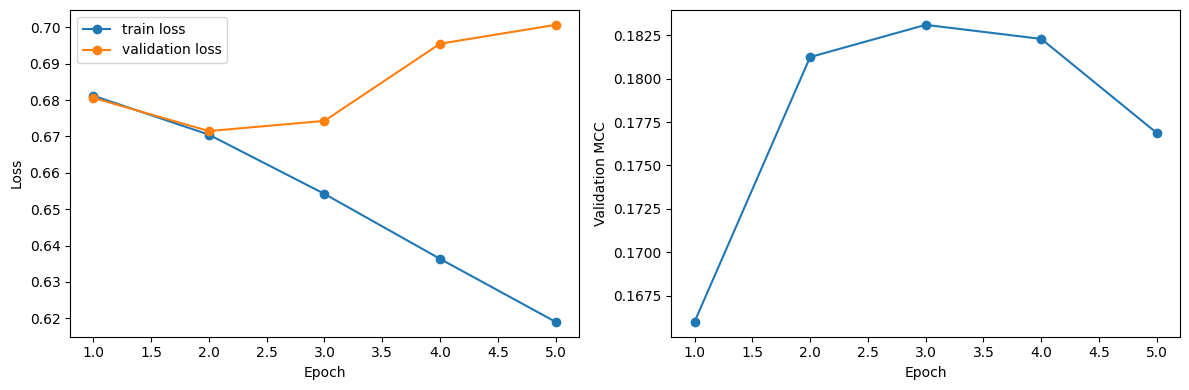

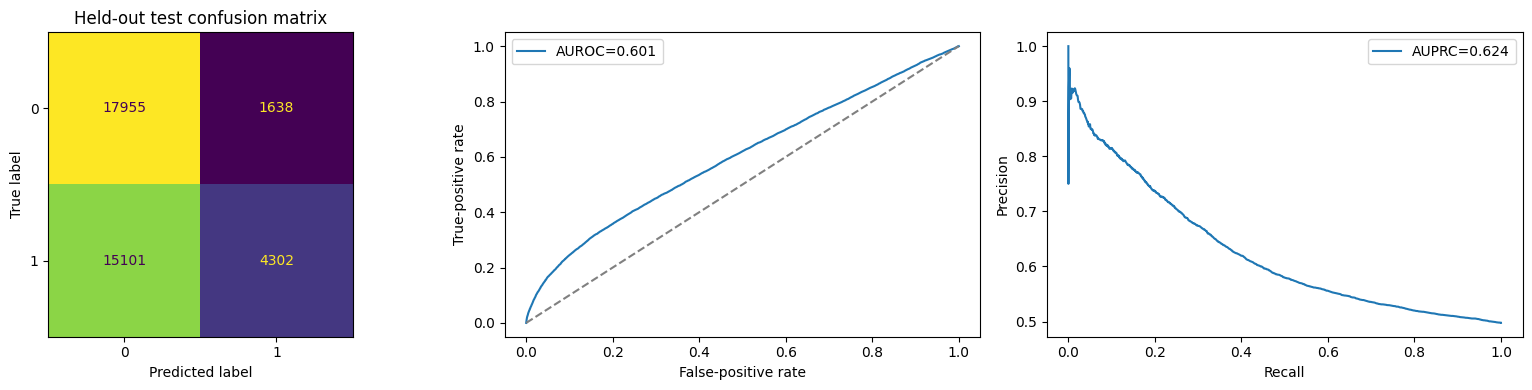

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, precision_recall_curve, roc_curve

history = pd.read_csv(history_path)
display(history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["epoch"], history["train_loss"], marker="o", label="train loss")
axes[0].plot(history["epoch"], history["validation_loss"], marker="o", label="validation loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history["epoch"], history["validation_mcc"], marker="o")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation MCC")
plt.tight_layout()
plt.show()

predictions = pd.read_csv(predictions_path)
test_predictions = predictions.loc[predictions["split"] == "test"].copy()
y_true = test_predictions["label"].to_numpy()
y_score = test_predictions["probability"].to_numpy()
y_pred = test_predictions["prediction"].to_numpy()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
ConfusionMatrixDisplay.from_predictions(y_true, y_pred, ax=axes[0], colorbar=False)
axes[0].set_title("Held-out test confusion matrix")

fpr, tpr, _ = roc_curve(y_true, y_score)
axes[1].plot(fpr, tpr, label=f"AUROC={float(test_metrics['auroc']):.3f}")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="grey")
axes[1].set_xlabel("False-positive rate")
axes[1].set_ylabel("True-positive rate")
axes[1].legend()

precision, recall, _ = precision_recall_curve(y_true, y_score)
axes[2].plot(recall, precision, label=f"AUPRC={float(test_metrics['auprc']):.3f}")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].legend()
plt.tight_layout()
plt.show()


## 14. Verify the reproducibility artifacts

In [14]:
required_artifacts = [
    "metrics.csv",
    "metrics.json",
    "predictions.csv",
    "manifest.json",
    "history.csv",
    "checkpoints/best_model.pt",
]

missing_artifacts = [
    relative_path
    for relative_path in required_artifacts
    if not (DRIVE_OUTPUT_DIR / relative_path).exists()
]
if missing_artifacts:
    raise FileNotFoundError(f"Missing benchmark artifacts: {missing_artifacts}")

print("Completed artifact set:")
for path in sorted(DRIVE_OUTPUT_DIR.rglob("*")):
    if path.is_file():
        print(path.relative_to(DRIVE_OUTPUT_DIR), path.stat().st_size, "bytes")

archive_path = Path(
    shutil.make_archive(
        str(DRIVE_OUTPUT_DIR),
        "zip",
        root_dir=DRIVE_OUTPUT_DIR.parent,
        base_dir=DRIVE_OUTPUT_DIR.name,
    )
)
print("Downloadable archive:", archive_path)


Completed artifact set:
checkpoints/best_model.pt 468337053 bytes
config.json 3364 bytes
history.csv 598 bytes
input_split_audit.json 873 bytes
manifest.json 5641 bytes
metrics.csv 885 bytes
metrics.json 1647 bytes
predictions.csv 56621739 bytes
Downloadable archive: /kaggle/working/dnabert2_final_training_t4_seed42.zip


## Interpretation and Kaggle hand-off

Use validation MCC to choose the checkpoint and probability threshold. Read
test MCC and AUPRC only after selection is complete; do not tune settings from
test results. If the result is promising, reproduce the selected settings with
the larger-resource profile before making the final model decision.

After the run finishes:

1. Confirm the metrics and plots above.
2. Click **Save Version** in Kaggle and choose **Save & Run All**.
3. Download `dnabert2_final_training_t4_seed42.zip` from the notebook's output
   files, or use the saved Kaggle notebook version as the persistent artifact.
